# 1. Reproduce results and coefficient reanalysis

<font size="4">

This notebook reconstructs the authors' analysis sample, reproduces the principal fixed-effects and instrumental-variable estimates, and checks what the reported coefficients and $R^2$ values measure.


For the paper titled ***China’s solar expansion policy reduces bird diversity*** published on ***Science*** Aug 20, 2026 <br>
https://doi.org/10.1126/science.aee0747
</font>

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import pyfixest as pf
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
DATA = NOTEBOOK_DIR.parent / "DATA"
assert DATA.is_dir()
sys.path.insert(0, str(NOTEBOOK_DIR))

from load_data import build_analysis_data, read_dta, make_full_observation_grid
from regression_utils import fit_fe
from iv_observer_sensitivity import build_iv_data, fit_instrument_observer_reduced_form, fit_iv
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
pd.set_option("display.float_format", lambda value: f"{value:.6g}")
print(f"Fixed-effects estimator: pyfixest {pf.__version__}")

Fixed-effects estimator: pyfixest 0.60.0


In [2]:
# Load the data for analysis
df, bird, policy = build_analysis_data(DATA) # df is the merged dataset that contains the latter two
df


,省,市,县,id,YEAR,month,year,标准年月,ShannonBD,SimpsonBD,BT,BN,PI,Temp,Wind,PD,CO2,PM25,Water,Green,Farm,Grass,ICtotal,Ndvi,Nightlight,LAI,Richness,PI_missing_in_source,BTN,Area,Pop,Duration,Carbon,PM,log_BN,log_BT,BT_zero,Evenness,county_month,trend,log_BN_w,log_BT_w,PI_lead1,PI_lead2,PI_lag1,PI_lag2
0,北京市,北京市,东城区,110101,2014,1,2014-01-01,2014-01,1.94591,0.857143,9,1,0,13.3974,1.94704,14149.9,1.49993e+06,87.4568,0.00832,0.00448,0.0235947,0,0,37.6985,63,0.0139986,7,1,9,0,9.50802,2.30259,14.2209,4.24596,0.693147,2.30259,0,1,110101_01,0,0.693147,2.30259,NaN,NaN,NaN,NaN
1,北京市,北京市,东城区,110101,2014,6,2014-06-01,2014-06,0.693147,0.5,0,1,0,13.3974,1.94704,14149.9,1.49993e+06,87.4568,0.00832,0.00448,0.0235947,0,0,37.6985,63,0.0139986,2,1,0,0,9.50802,0,14.2209,4.24596,0.693147,0,1,1,110101_06,5,0.693147,0,NaN,NaN,NaN,NaN
2,北京市,北京市,东城区,110101,2014,8,2014-08-01,2014-08,2.94467,0.921491,11,2,0,13.3974,1.94704,14149.9,1.49993e+06,87.4568,0.00832,0.00448,0.0235947,0,0,37.6985,63,0.0139986,29,1,5.5,0,9.50802,1.8718,14.2209,4.24596,1.09861,2.48491,0,0.87449,110101_08,7,1.09861,2.48491,NaN,NaN,NaN,NaN
3,北京市,北京市,东城区,110101,2014,9,2014-09-01,2014-09,1.79176,0.833333,12,1,0,13.3974,1.94704,14149.9,1.49993e+06,87.4568,0.00832,0.00448,0.0235947,0,0,37.6985,63,0.0139986,6,1,12,0,9.50802,2.56495,14.2209,4.24596,0.693147,2.56495,0,1,110101_09,8,0.693147,2.56495,NaN,NaN,NaN,NaN
4,北京市,北京市,东城区,110101,2014,10,2014-10-01,2014-10,1.38629,0.75,23,2,0,13.3974,1.94704,14149.9,1.49993e+06,87.4568,0.00832,0.00448,0.0235947,0,0,37.6985,63,0.0139986,4,1,11.5,0,9.50802,2.52573,14.2209,4.24596,1.09861,3.17805,0,1,110101_10,9,1.09861,3.17805,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46523,新疆维吾尔自治区,,胡杨河市,659010,2023,5,2023-05-01,2023-05,3.70542,0.966906,187.983,14,0,9.89877,2.44119,33.1208,3.82942e+06,29.4492,0.00279704,1.36109e-05,0.74361,0.190099,450,69.608,6.29618,0.666064,NaN,0,13.4274,3,3.50016,2.66913,15.1582,3.38267,2.70805,5.24166,0,NaN,659010_05,112,2.70805,5.24166,NaN,NaN,0,0
46524,新疆维吾尔自治区,,胡杨河市,659010,2023,6,2023-06-01,2023-06,2.48049,0.896786,11.75,7,0,9.89877,2.44119,33.1208,3.82942e+06,29.4492,0.00279704,1.36109e-05,0.74361,0.190099,450,69.608,6.29618,0.666064,NaN,0,1.67857,3,3.50016,0.985284,15.1582,3.38267,2.07944,2.54553,0,NaN,659010_06,113,2.07944,2.54553,NaN,NaN,0,0
46525,新疆维吾尔自治区,,胡杨河市,659010,2023,7,2023-07-01,2023-07,3.03498,0.94229,8.93333,10,0,9.89877,2.44119,33.1208,3.82942e+06,29.4492,0.00279704,1.36109e-05,0.74361,0.190099,450,69.608,6.29618,0.666064,NaN,0,0.893333,3,3.50016,0.638339,15.1582,3.38267,2.3979,2.2959,0,NaN,659010_07,114,2.3979,2.2959,NaN,NaN,0,0
46526,新疆维吾尔自治区,,胡杨河市,659010,2023,8,2023-08-01,2023-08,1.94591,0.857143,6.35,1,0,9.89877,2.44119,33.1208,3.82942e+06,29.4492,0.00279704,1.36109e-05,0.74361,0.190099,450,69.608,6.29618,0.666064,NaN,0,6.35,3,3.50016,1.9947,15.1582,3.38267,0.693147,1.9947,0,NaN,659010_08,115,0.693147,1.9947,NaN,NaN,0,0


<font size="4">

Note that here the PI variable is referred as photovoltaic policy stringency index (PSI) in the published paper. Also notice that although they named it a column `year` but this variable is actually `year-month`... The capitalization of the variable YEAR is the true year variable. I didn't change the naming to make it consistent with those in the paper.

</font>

<Axes: xlabel='YEAR'>

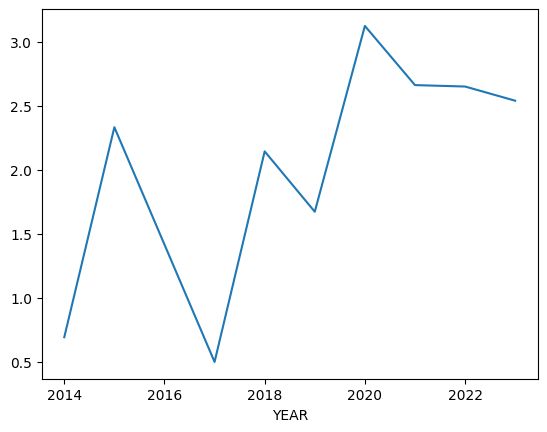

In [3]:
df[(df['省']=='北京市') & (df['市']=='北京市') & (df['县']=='东城区') & (df['month']==6)
     ].set_index('YEAR')['ShannonBD'].plot()

<Axes: xlabel='YEAR'>

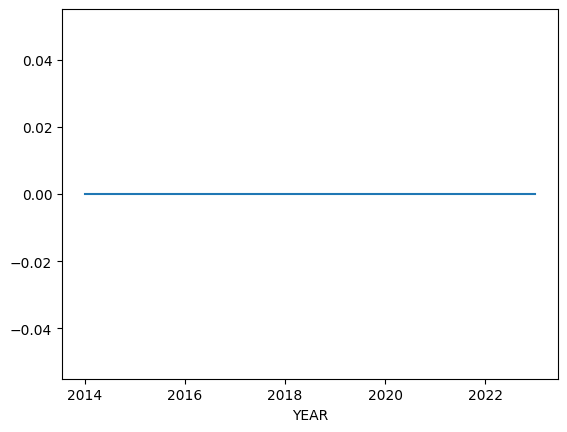

In [4]:
df[(df['省']=='北京市') & (df['市']=='北京市') & (df['县']=='东城区') & (df['month']==6)
     ].set_index('YEAR')['PI'].plot()


In [5]:

df = df[df.groupby("id")["id"].transform("size") > 1].copy() # singletons were removed implicitly in their code

controls = ["Temp", "Wind", "Pop", "Duration", "Carbon", "Water", "Green", "Farm", "Grass"]

def result_row(label, result, term="PI"): # Will use this function multiple times
    return {
        "model": label,
        "coefficient": result[f"coef_{term}"],
        "clustered_se": result[f"se_{term}"],
        "p_value": result[f"p_{term}"],
        "n": result["n"],
        "within_r2": result["within_r2"],
        "partial_r2": result["partial_r2_focal"],
    }

print(f"Analysis sample: {len(df):,} county-months, {df['id'].nunique():,} counties")

Analysis sample: 46,371 county-months, 2,344 counties


## Reproduce Table 1

In [ ]:
specifications = {
    "PSI only": ["PI"],
    "PSI + socioeconomic controls": ["PI", "Temp", "Wind", "Pop", "Duration", "Carbon"],
    "Released full controls": ["PI", *controls], # PSI + socioeconomic controls + environmental (land cover) variables
}

table1_fits = {
    label: fit_fe(df, "ShannonBD", regressors, label=label)
    for label, regressors in specifications.items()
}
released = table1_fits["Released full controls"]

display(pd.DataFrame(table1_fits).T)



<font size="4">

The fully controlled estimate reproduces the paper: 

- PSI coefficient $=-0.01253$, 
- county-clustered SE $=0.00365$, and 
- $P=0.00061$. 

County and year-month fixed effects mean this is a **within-county, relative-to-the-national-month** association, not a cross-county comparison.
</font>

## We then calculate and decompose the reported adjusted $R^2$ in the table 1 of the paper

### For the Table 1 in the paper

In [ ]:
def adjusted_r2(r2, n, absorbed_df, slopes): # Panelty for flexibility/overfitting/overparameterization, as in the paper
    return 1 - (1 - r2) * (n - 1) / (n - absorbed_df - slopes)

psi_only = table1_fits["PSI only"]
controls_only = fit_fe(df, "ShannonBD", controls, focal=None) # no PSI
n = psi_only["n"]
absorbed_df = df["id"].nunique() + df["year"].nunique() - 1

psi_increment = psi_only["overall_r2"] - psi_only["fe_only_r2"]
full_increment = released["overall_r2"] - controls_only["overall_r2"]

r2_reanalysis = pd.DataFrame({
    "quantity": [
        "Reported model 1 adjusted overall R2",
        "Fixed-effects-only adjusted overall R2",
        "Model 1 within R2 for PSI",
        "Model 1 incremental overall R2",
        "Full-model partial R2 for PSI",
        "PSI share of full-model explained sum of squares",
    ],
    "value": [
        adjusted_r2(psi_only["overall_r2"], n, absorbed_df, 1),
        adjusted_r2(psi_only["fe_only_r2"], n, absorbed_df, 0),
        psi_only["within_r2"],
        psi_increment,
        released["partial_r2_focal"],
        full_increment / released["overall_r2"],
    ],
})
r2_reanalysis["percent"] = 100 * r2_reanalysis["value"]
r2_reanalysis['note'] = [
    'Table 1, column 1 in the paper',
    'Only fixed effects (county and year-month), no PSI',
    'The TRUE PSI effect, after the fixed effects are accounted for. It measures PSI’s contribution among the variation left after county and time effects',
    'It measures the same contribution relative to all variation in bird diversity. It is smaller because it also has the fixed effect in the denominator.',
    'When experimentally remove PSI, what percentage of the overall R^2 is lost.',
    'Among the overall R^2, what is the percentage being explained by PSI.'
]

with pd.option_context("display.max_colwidth", None):
    display(r2_reanalysis.style.set_properties(**{"text-align": "left"}))


,quantity,value,percent,note
0,Reported model 1 adjusted overall R2,0.271533,27.153339,"Table 1, column 1 in the paper"
1,Fixed-effects-only adjusted overall R2,0.271016,27.101592,"Only fixed effects (county and year-month), no PSI"
2,Model 1 within R2 for PSI,0.000733,0.073260,"The TRUE PSI effect, after the fixed effects are accounted for. It measures PSI’s contribution among the variation left after county and time effects"
3,Model 1 incremental overall R2,0.000506,0.050570,It measures the same contribution relative to all variation in bird diversity. It is smaller because it also has the fixed effect in the denominator.
4,Full-model partial R2 for PSI,0.000478,0.047834,"When experimentally remove PSI, what percentage of the overall R^2 is lost."
5,PSI share of full-model explained sum of squares,0.000941,0.094068,"Among the overall R^2, what is the percentage being explained by PSI."


<font size="4">

Here, by comparing row 0 and row 1, we see that the 27.15% variance explained is mostly contributed by fixed effect, namely, county and year, which means that it captures the spatial and temporal variation of ShannonBD index, not the effect of PSI. The originally published paper may **mistakenly** include fixed effect in their $R^2$ calculation.

Additionally, the effect of PSI explains **only 0.048%–0.094%** of the variance, depending on how the $R^2$ is defined and how rigorous the definition is, instead of the claimed 27.15%.
</font>

### For the Table 2 in the paper

In [ ]:
mechanism_rows = []
for outcome in ["Ndvi", "Nightlight", "LAI"]:
    full = fit_fe(df, outcome, ["PI", *controls])
    reduced = fit_fe(df, outcome, controls, focal=None)
    time_count = df.loc[df[outcome].notna(), "year"].nunique()
    absorbed = full["clusters"] + time_count - 1
    mechanism_rows.append({
        "outcome": outcome,
        "reported_adjusted_overall_r2": adjusted_r2(
            full["overall_r2"], full["n"], absorbed, 1 + len(controls)
        ),
        "fixed_effects_only_r2": full["fe_only_r2"],
        "partial_r2_PSI": full["partial_r2_focal"],
        'Coef_PSI_in_full_model': full['coef_PI'],
    })

display(pd.DataFrame(mechanism_rows))

,outcome,reported_adjusted_overall_r2,fixed_effects_only_r2,partial_r2_PSI,Coef_PSI_in_full_model
0,Ndvi,0.991745,0.991458,0.00362325,-0.0609212
1,Nightlight,0.991471,0.991101,0.0256506,-0.222002
2,LAI,0.992149,0.992385,0.00749815,0.00393507


<font size="4">

The surprisingly high Table 2 values near 0.992 are also dominated by fixed effects. Statistical significance is therefore not evidence of large explanatory power given this large sample size.

Given these small $R^2$, it is likely that PSI shows very minimum effect on any of these three variables, and that none of the reasoning of about the "causal pathways" in the paper is robust.

Another detail is that the authors also include "Duration" in this regression, while this regression has nothing to do with birds. This is a model misspecification.

</font>

## Check the proposed physical pathway

In [ ]:
annual_area = (
    df.groupby(["id", "YEAR"], as_index=False)[["Area", "PI", *controls]]
      .mean()
)

paper_area_model = pf.feols(
    f"Area ~ PI + {' + '.join(controls)}",
    data=annual_area,
    vcov="iid",
)

display(pd.DataFrame({
    "coefficient": [paper_area_model.coef()["PI"]],
    "P value": [2 * stats.t.sf(abs(paper_area_model.coef()['PI'] / paper_area_model.se()['PI']), df=paper_area_model._N - len(controls) - 2 # The pyfixed will round P to zero so we manually calculate them
)],
    "standard error": [paper_area_model.se()["PI"]],
    "n": [paper_area_model._N],
}))

display(pd.DataFrame([{"quantity": "Contemporaneous annual PSI-area correlation", "value": annual_area["PI"].corr(annual_area["Area"])}]))


,coefficient,P value,standard error,n
0,0.0221854,3.07342e-17,0.00262337,11666


,quantity,value
0,Contemporaneous annual PSI-area correlation,0.041446


<font size="4">

Here we reproduced the results in the paper β = 0.0222, standard error (SE) = 0.0026, P < 0.01; fig. S2 and table S6. The coefficient is significant here. However, it changed to non-significant when we include county and year as the fixed effect. It's confusing why the authors used county and year as the fixed effect in most of the analyses but not this one.

</font>

In [ ]:
area_stage = fit_fe(df, "Area", ["PI", *controls])
joint_area = fit_fe(df, "ShannonBD", ["PI", "Area", *controls])

display(pd.DataFrame([
    result_row("PSI predicts inferred PV area", area_stage),
    result_row("PSI coefficient after controlling inferred area", joint_area),
]))


,model,coefficient,clustered_se,p_value,n,within_r2,partial_r2
0,PSI predicts inferred PV area,-0.000191035,0.00661105,0.97695,46371,0.0234412,3.59524e-07
1,PSI coefficient after controlling inferred area,-0.0125358,0.00365097,0.000606096,46371,0.0402491,0.000479125


<font size="4">

The contemporaneous PSI-area correlation is only 0.0414. In the same fixed-effects specification, PSI does not predict inferred installation area, and adding area leaves the PSI coefficient essentially unchanged (-0.0125). This shows that the estimated policy coefficient is not empirically connected to contemporaneous installed area.

Given this low correlation, one can hardly accept the argument that PV area is ***"an alternative measure of photovoltaic policy stringency"***. Additionally the figure S2 and S3 in the supplementary materials are camouflaged, since they used ***binned scatter plot*** to disguise the apparently large variance in the data. The authors' argument in the caption ***"The positive slope suggests a statistically significant association between the two variables, confirming that regions with stronger PV policy stringency tend to exhibit larger physical deployment of solar infrastructure"*** is therefore ungrounded. This is supported by the fact that when regressing PV area against PSI, the $R^2s$ are close to zero (the table right above). Therefore, even though the authors discussed in the main text that PSI positively correlates with PV area, with beta=0.0222, p<0.01, such correlation is likely trivial, with the statistical significance mostly contributed by the large sample size.

From a scientific perspective, I also found it hard to understand the authors' motivation to use PSI instead of PV area as the predictor of biodiversity. Physical land cover change is logically a more appropriate predictor for animal populations when compared with unimplemented governmental plans and policies.
</font>

## Reproduce the released IV estimate

In [ ]:
iv_data = build_iv_data(DATA)
released_iv = fit_iv(iv_data, add_observer_count=False)
display(pd.DataFrame([released_iv]))


,model,n,clusters,estimator,pi_coefficient,pi_clustered_se,pi_p_value,first_stage_instrument_coefficient,first_stage_instrument_clustered_se,first_stage_instrument_p_value
0,Released Table S7 IV,37503,2077,pyfixest 0.60.0,-0.126369,0.0346277,0.000269381,0.0252042,0.0045805,4.20688e-08


<font size="4">

Here we successfully reproduced the first_stage_instrument_coefficient = 0.0252, corresponding to the row 1, column 1 in Table S7 of the paper, as well as its se (0.0046). We also reproduced the pi_coefficient = -0.126 and se 0.0346, corresponding to row 2 line 2 in Table S7.


In causal inference, to make $log(historical\ sunshine)/CPU$ a legitimate Instrumental Variable (IV), it must satisfy that the IV influences PSI, but does not influence observed bird diversity. However, this assumption may break, since reduced climate-policy uncertainty could mean the county turning into a more "eco-friendly" era, which could be related to more birder and more experienced birder taking more checklists, resulting in higher observed biodiversity.

We show that our concern is supported by data (see analyses in the next notebook).
</font>

## Conclusion

<font size="4">


The authors’ fixed-effects and IV coefficients can be reproduced from the released data, but numerical replication does not establish their proposed causal interpretation. 

PSI explains only 0.073% of the variation remaining after fixed effects in the PSI-only model and has a partial $R^2$ of 0.048% in the full model. The mechanism models’ overall $R^2$ values near 0.992 are largely attributable to fixed effects, while PSI’s conditional partial $R^2$ ranges from 0.36% to 2.57%. 

Moreover, the contemporaneous PSI–Area correlation is only 0.041, and PSI does not predict inferred PV area in the corresponding controlled two-way fixed-effects model ($\beta=-0.00019$, $p=0.977$); controlling for Area leaves the PSI coefficient essentially unchanged. 

The IV estimate also reproduces, but its causal meaning remains dependent on an unverified exclusion restriction. The released aggregate data therefore support a statistical association between PSI and recorded bird diversity, but do not by themselves identify solar-policy-driven land conversion as its cause.

</font>